In [1]:
import numpy as np
import pandas as pd


In [3]:
df  = pd.read_csv("/content/placement.csv")

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df.shape

(100, 4)

In [7]:
df  = df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt


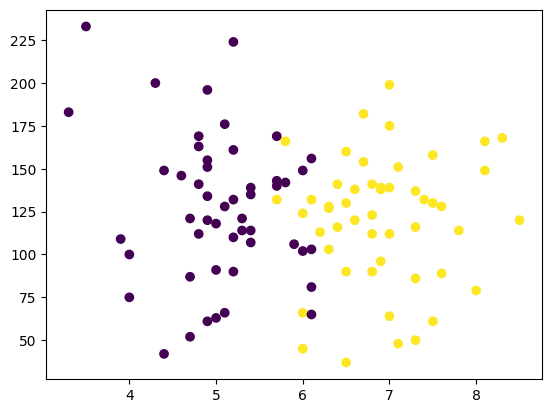

In [10]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [11]:
X =  df.iloc[:,0:2]
y = df.iloc[:,-1]

In [12]:
X


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [13]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.1)

In [16]:
X_train

,cgpa,iq
77,7.3,50.0
64,7.0,64.0
13,6.4,116.0
92,5.2,110.0
50,3.5,233.0
...,...,...
60,6.9,139.0
6,5.7,143.0
56,6.1,65.0
58,8.0,79.0


In [17]:
y_train

,placement
77,1
64,1
13,1
92,0
50,0
...,...
60,1
6,0
56,0
58,1


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train = scaler.fit_transform(X_train)

In [21]:
X_train

array([[ 1.19613679, -1.85086525],
       [ 0.93206734, -1.49741114],
       [ 0.40392845, -0.18458159],
       [-0.65234934, -0.33606192],
       [-2.14874286,  2.7692849 ],
       [ 2.25241457, -0.0835947 ],
       [ 0.75602104, -0.00785454],
       [ 0.139859  , -1.06821686],
       [-1.09246508, -1.80037181],
       [-1.00444193, -0.28556848],
       [ 0.4919516 , -0.84099637],
       [ 0.93206734,  0.39609302],
       [ 0.139859  , -0.51278898],
       [-0.65234934,  0.9515209 ],
       [ 0.75602104, -0.28556848],
       [ 1.19613679,  0.34559957],
       [-0.56432619, -0.23507503],
       [-0.21223359,  0.42133974],
       [-1.79665027, -0.36130865],
       [ 0.4919516 ,  0.16887252],
       [-0.91641878,  0.80004057],
       [-1.00444193,  1.00201435],
       [ 1.19613679, -0.94198325],
       [-0.91641878,  0.69905368],
       [ 0.139859  ,  0.21936596],
       [ 0.05183585, -0.5380357 ],
       [-1.00444193,  0.44658646],
       [ 0.3159053 , -0.51278898],
       [ 0.4919516 ,

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
clf = LogisticRegression()

In [24]:
clf.fit(X_train,y_train)

LogisticRegression()

In [26]:
y_predict = clf.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test,y_predict)

0.7

In [30]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

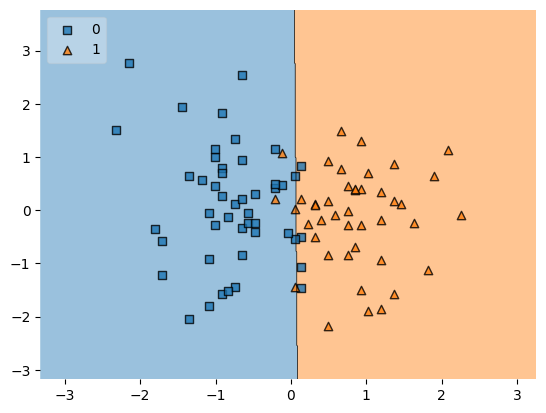

In [31]:

plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [33]:
import pickle

In [34]:
pickle.dump(clf,open('model.pkl','wb'))